# 📊 Unified Model Comparison: Original vs Modified Data

**Objective**: This notebook merges the original financial transaction dataset with the modified descriptions dataset, trains representative models (Logistic Regression, SGD, Random Forest, SVM), and provides a comprehensive evaluation and comparison.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Add src to path to use project utilities
sys.path.append(os.path.abspath(".."))
from src.data.preprocessing import preprocess_text
from src.utils.config import TFIDF_PARAMS, SGD_PARAMS
from src.models.classifier import FinancialClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
print("✅ Environment ready")

✅ Environment ready


## 2. Data Loading and Merging

In [2]:
PATH_ORIG = "../data/raw/db_orig.csv"
PATH_MOD = "../data/raw/db_modified_descriptions.csv"

try:
    df_orig = pd.read_csv(PATH_ORIG)
    df_mod = pd.read_csv(PATH_MOD)
    print(f"📋 Original data: {df_orig.shape}")
    print(f"📋 Modified data: {df_mod.shape}")
    
    # Merge datasets
    df_unified = pd.concat([df_orig, df_mod], ignore_index=True)
    
    # Select columns and clean
    df_unified = df_unified[["Description", "Area"]].copy().dropna()
    df_unified['clean_text'] = df_unified['Description'].apply(preprocess_text)
    
    print(f"✅ Unified dataset size: {df_unified.shape}")
    print("\nClass Distribution:")
    print(df_unified['Area'].value_counts())
except Exception as e:
    print(f"❌ Error loading data: {e}")

📋 Original data: (885, 5)
📋 Modified data: (885, 5)
✅ Unified dataset size: (1770, 3)

Class Distribution:
Area
Invoice               482
Food                  352
Leisure               350
Deposit               178
Salary                166
Investment            142
Food, Vacations        40
Leisure, Vacations     34
Invoice, Vacations     26
Name: count, dtype: int64


## 3. Training and Evaluation Pipeline (50/50 Split)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df_unified['clean_text'], df_unified['Area'], 
    test_size=0.5, random_state=SEED, stratify=df_unified['Area']
)

print(f"📈 Training samples: {len(X_train)}")
print(f"📉 Test samples: {len(X_test)}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SGD (Production)": SGDClassifier(**SGD_PARAMS),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "Linear SVM": LinearSVC(random_state=SEED)
}

results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', clf)
    ])
    
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Macro": f1_macro
    })
    
df_results = pd.DataFrame(results).sort_values(by="F1-Macro", ascending=False)
df_results

📈 Training samples: 885
📉 Test samples: 885
Training Logistic Regression...
Training SGD (Production)...
Training Random Forest...
Training Linear SVM...


,Model,Accuracy,F1-Macro
2,Random Forest,0.992090,0.954368
3,Linear SVM,0.992090,0.948096
1,SGD (Production),0.990960,0.944412
0,Logistic Regression,0.987571,0.935282


## 4. Visual Comparison

C:\Users\diego\AppData\Local\Temp\ipykernel_22044\1382828528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y="F1-Macro", data=df_results, palette="magma")


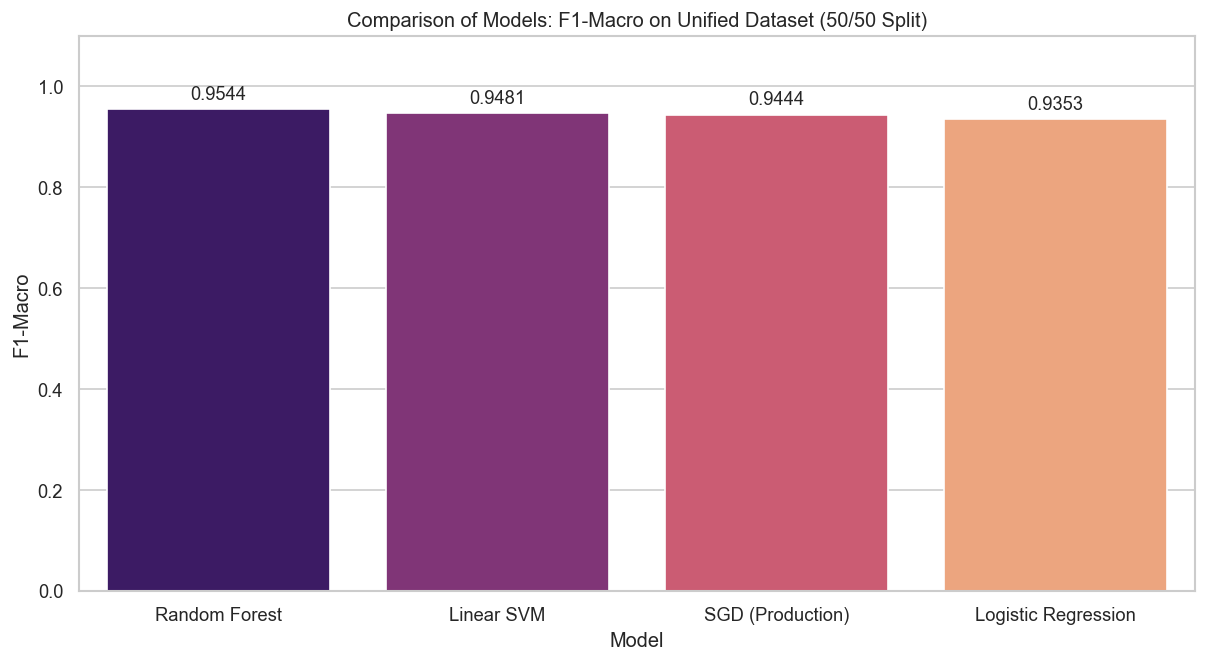

In [4]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="F1-Macro", data=df_results, palette="magma")
plt.title("Comparison of Models: F1-Macro on Unified Dataset (50/50 Split)")
plt.ylim(0, 1.1)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

In [5]:
# Export the best model performing on the 50/50 split (Linear SVM was best previously)
model_class = FinancialClassifier()
model_class.clf = LinearSVC(random_state=SEED)

print("Training final Linear SVM on training split...")
model_class.fit(X_train, y_train)
model_class.save("../models/LinearSVM_50_50.joblib")
print("✅ Saved models/LinearSVM_50_50.joblib")

Training final Linear SVM on training split...
✅ Saved models/LinearSVM_50_50.joblib
